In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [71]:
df_network_org_org = pd.read_excel('../data/BAAD_Insurgency_1998-2015_Release_1.xlsx',
                                   sheet_name='Network Org-Org')

df_network_state_org = pd.read_excel('../data/BAAD_Insurgency_1998-2015_Release_1.xlsx',
                                   sheet_name='Network State-Org')

df_attack = pd.read_csv('../data/globalterrorism_filtered.csv')

/home/jc820/Documents/academic/PhD_research/sandia/sandia_venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/tmp/ipykernel_6969/2916348624.py:7: DtypeWarning: Columns (61,62,63,79,94,96,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attack = pd.read_csv('../data/globalterrorism_filtered.csv')


# Network data

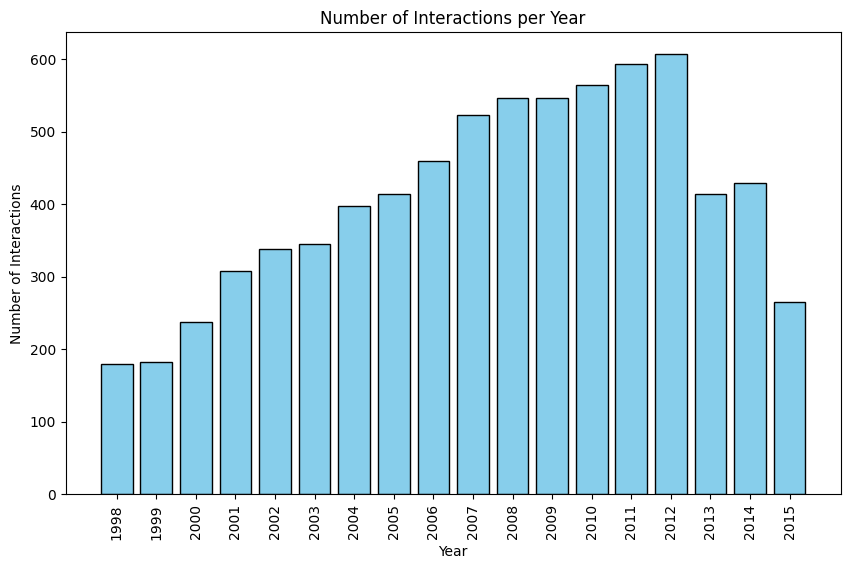

In [72]:
# Create an empty list to store the year and count
years = []
counts = []

# Collect the data
for year in np.arange(1998, 2016):
    df_year = df_network_org_org[df_network_org_org.YEAR == year]
    years.append(year)
    counts.append(len(df_year))

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(years, counts, color='skyblue', edgecolor='black')

plt.title("Number of Interactions per Year")
plt.xlabel("Year")
plt.ylabel("Number of Interactions")
plt.xticks(np.arange(1998, 2016, 1), rotation=90)  # Ensure all years are displayed
plt.show()

In [73]:
# Initialize an empty dictionary to store the value counts for each year
value_counts_by_year = {}

# Loop through each year from 1998 to 2015
for year in range(1998, 2016):
    df_year = df_network_org_org[df_network_org_org.YEAR == year]    
    df_year = df_year.reset_index(drop=True)
    df_year = df_year[['SIDCODE', 'RIDCODE', 'AFFLIATN']]
    
    # Get the value counts of the 'AFFLIATN' column
    value_counts = df_year.AFFLIATN.value_counts()
    
    # Store the result in the dictionary with the year as the key
    value_counts_by_year[year] = value_counts

df_value_counts = pd.DataFrame(value_counts_by_year)
df_value_counts.fillna(0, inplace=True)
df_value_counts = df_value_counts.astype(int)
df_value_counts

,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
AFFLIATN,,,,,,,,,,,,,,,,,,
1,5,6,7,7,5,6,10,6,9,11,9,10,7,9,13,7,9,4
2,0,0,0,1,0,2,6,0,0,0,0,0,4,2,3,0,1,0
3,18,18,18,19,20,24,30,35,39,38,40,41,39,44,44,18,18,16
4,3,3,5,5,5,5,5,5,6,6,6,6,5,5,5,0,0,0
5,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0
6,124,112,148,188,204,201,234,247,290,317,305,344,346,367,394,291,300,197
7,10,16,26,56,68,73,82,76,58,77,132,105,125,123,116,98,101,48
8,9,14,18,17,23,23,20,22,26,31,27,23,24,22,22,0,0,0
9,9,13,13,12,10,8,8,20,29,40,25,15,11,18,7,0,0,0


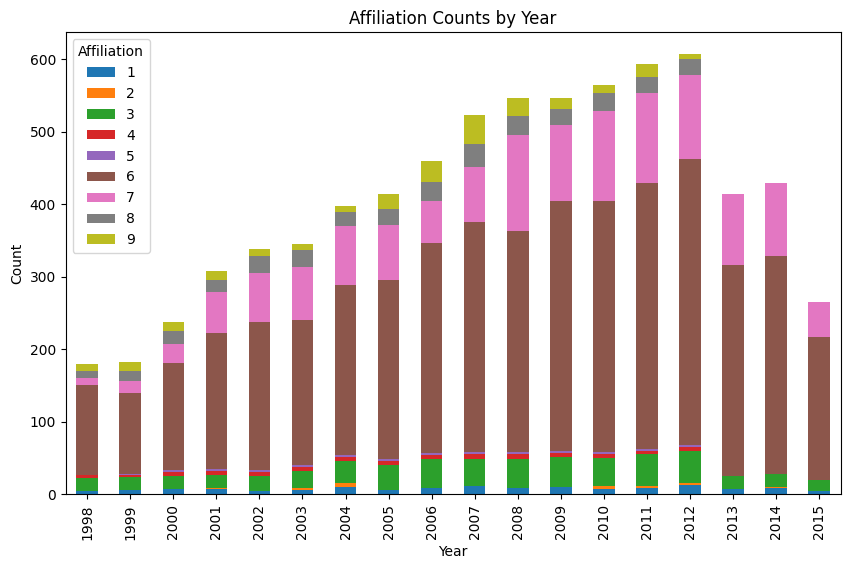

In [74]:
df_value_counts.T.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Affiliation Counts by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Affiliation")
plt.show()

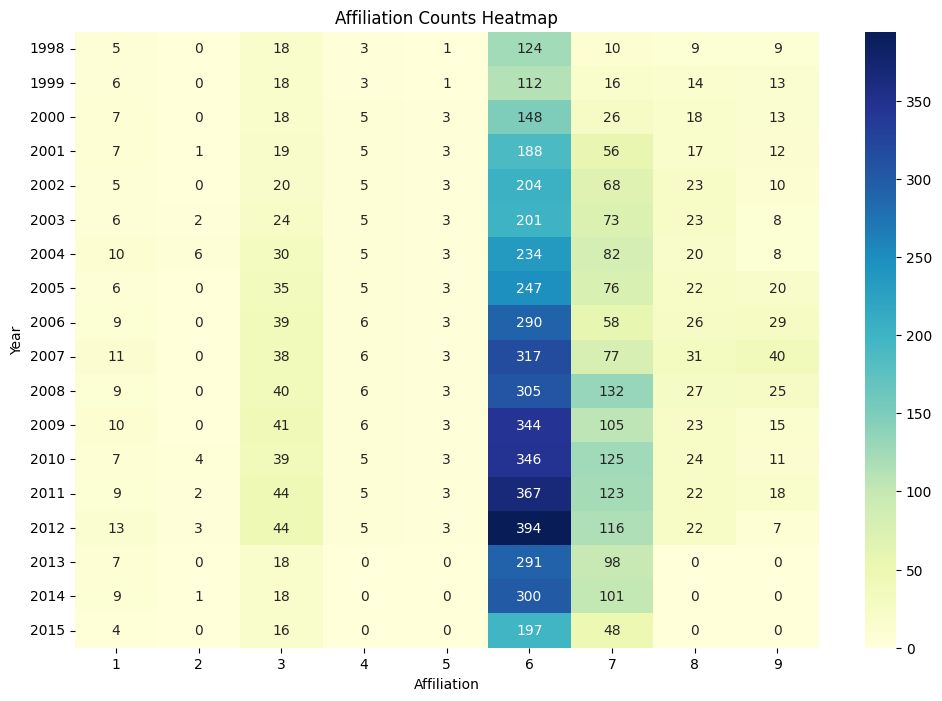

In [75]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_value_counts.T, cmap="YlGnBu", annot=True, fmt='d')

plt.title("Affiliation Counts Heatmap")
plt.xlabel("Affiliation")
plt.ylabel("Year")
plt.show()

In [99]:
year = 2012
network_org_org = (df_network_org_org.loc[df_network_org_org.YEAR == year,
                                         ['SIDCODE', 'RIDCODE', 'AFFLIATN']]
                   .reset_index(drop=True))

# Create a mapping and map nodes to integers
SIDCODE_unique = network_org_org.SIDCODE.unique()
RIDCODE_unique = network_org_org.RIDCODE.unique()
CODE_unique = np.unique(np.concatenate((SIDCODE_unique, RIDCODE_unique)))
SNDORG_unique = df_network_org_org.SNDORG.unique()
RCVORG_unique = df_network_org_org.RCVORG.unique()
NAME_unique = np.unique(np.concatenate((SNDORG_unique, RCVORG_unique)))

CODE_to_node_map = {}
for i,j in enumerate(CODE_unique):
    CODE_to_node_map[int(j)] = int(i)
    
node_to_CODE_map = {value: key for key, value in CODE_to_node_map.items()}

# name_to_CODE_map = {}
# for i, name in enumerate(NAME_unique):
#     name_to_CODE_map[name] = node_to_CODE_map[i]
    
network_org_org['SIDCODE'] = network_org_org['SIDCODE'].map(CODE_to_node_map)
network_org_org['RIDCODE'] = network_org_org['RIDCODE'].map(CODE_to_node_map)

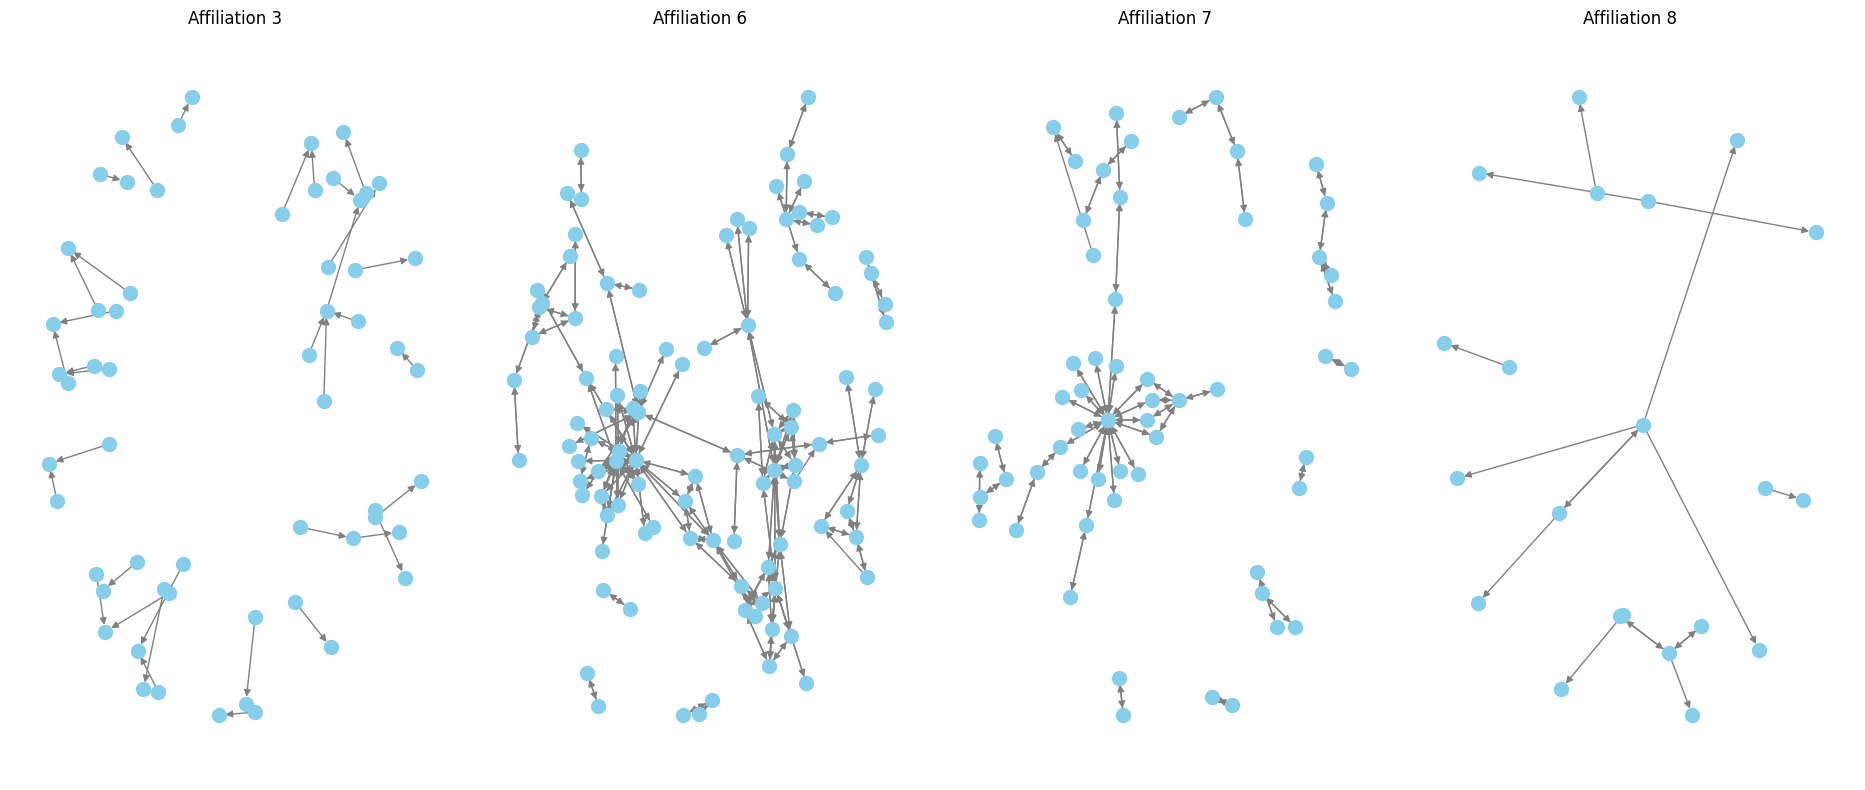

In [87]:
affiliations = network_org_org.AFFLIATN.unique()
# Create a figure for visualization
plt.figure(figsize=(42, 8))

# Create a graph for each affiliation
for idx, aff in enumerate([3,6,7,8], start=1):
    sub_df = network_org_org[network_org_org['AFFLIATN'] == aff]
    
    G = nx.from_pandas_edgelist(sub_df, 'SIDCODE', 'RIDCODE', create_using=nx.DiGraph())
    
    # Define the layout with more separation (adjust 'k' to change spacing)
    pos = nx.spring_layout(G, k=0.3, seed=42)  # 'k' controls the separation (larger value -> more spacing)

    # Draw the graph
    plt.subplot(1, len(affiliations), idx)
    nx.draw(G, pos, with_labels=False, node_color='skyblue', edge_color='gray', node_size=100)
    plt.title(f'Affiliation {aff}')

plt.tight_layout()
plt.show()

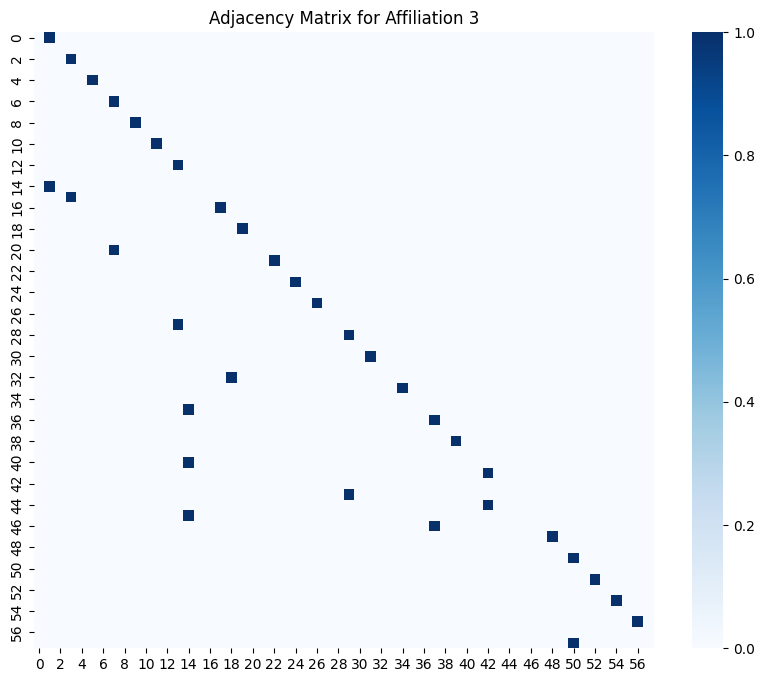

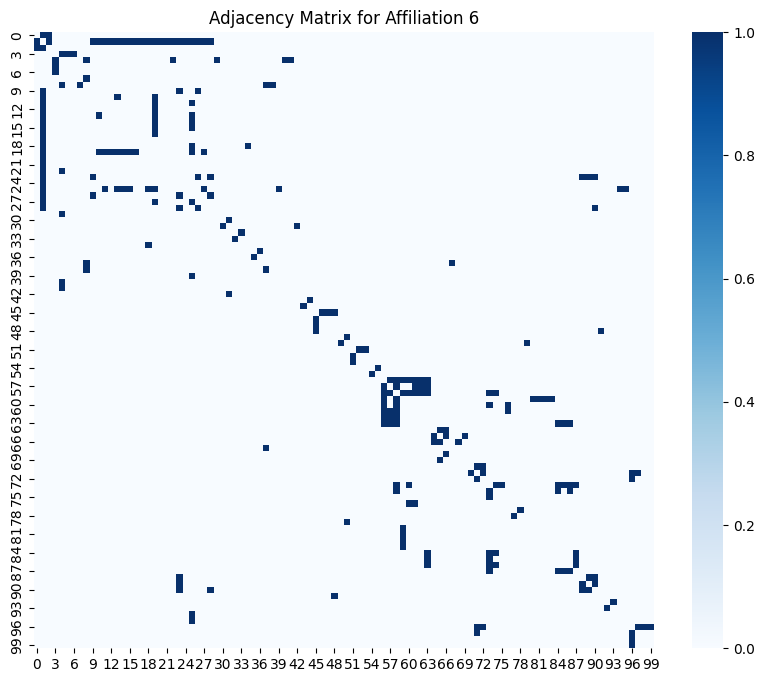

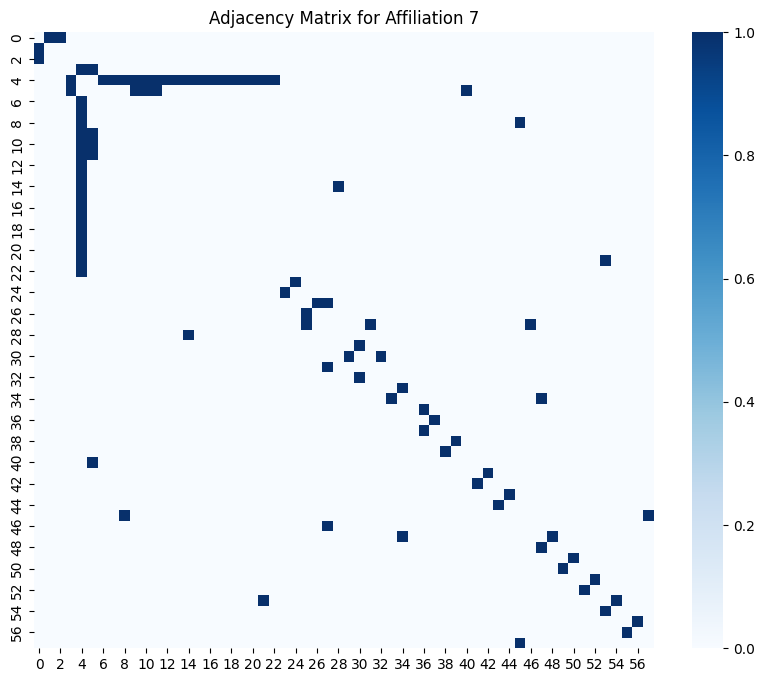

In [160]:
for aff in [3,6,7]:
    sub_df = network_org_org[network_org_org['AFFLIATN'] == aff]
    
    # Create a directed graph for the current affiliation (layer)
    G = nx.from_pandas_edgelist(sub_df, 'SIDCODE', 'RIDCODE', create_using=nx.DiGraph())
    
    # Get the adjacency matrix
    adjacency_matrix = nx.adjacency_matrix(G).todense()
    
    # Get the degree matrix (out-degree by default in directed graphs)
    degrees = np.diag([G.out_degree(node) for node in G.nodes()])
    
    # Optionally, get the in-degree matrix if you want:
    in_degrees = np.diag([G.in_degree(node) for node in G.nodes()])
    
    # Visualizing the Adjacency Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(adjacency_matrix, annot=False, cmap="Blues", cbar=True)
    plt.title(f'Adjacency Matrix for Affiliation {aff}')
    plt.show()


In [79]:
network_unique_groups = df_network_org_org['SNDORG'].unique()

# Attack data

In [85]:
# Ensure that all the date-related columns are integers
df_attack['iyear'] = df_attack['iyear'].astype(int)
df_attack['imonth'] = df_attack['imonth'].astype(int)
df_attack['iday'] = df_attack['iday'].astype(int)

# Manually create a 'YYYY-MM-DD' string column
df_attack['year_month_day'] = df_attack.apply(lambda row: f"{row['iyear']}-{row['imonth']:02d}-{row['iday']:02d}", axis=1)

# Convert the string column to datetime, coercing any errors
df_attack['year_month_day'] = pd.to_datetime(df_attack['year_month_day'], format="%Y-%m-%d", errors='coerce')

# Calculate seconds since the earliest valid date
earliest_date = df_attack['year_month_day'].min()
df_attack['seconds_since_earliest'] = (df_attack['year_month_day'] - earliest_date).dt.total_seconds()

# Restrict to only attackers that are in the network
df_attack_network = df_attack[df_attack.gname.isin(network_unique_groups)].reset_index(drop=True)

# Take relevant columns
df_attack_network = df_attack_network[['gname','year_month_day', 'iyear', 'seconds_since_earliest', 'region', 'latitude', 'longitude']]

In [157]:
# Restrict to a year and rest 'seconds_since_earliest' 
year = 2013
df_attack_network_year = df_attack_network[df_attack_network.iyear == year].reset_index(drop=True)
df_attack_network_year['seconds_since_earliest'] = df_attack_network_year['seconds_since_earliest'] - df_attack_network_year['seconds_since_earliest'].min()

# Map gname to integer
unique_gname = df_attack_network_year.gname.unique()

gname_to_int_map = {}
for i, name in enumerate(unique_gname):
    gname_to_int_map[name] = int(i)
    
df_attack_network_year['group_int'] = df_attack_network_year['gname'].map(gname_to_int_map)

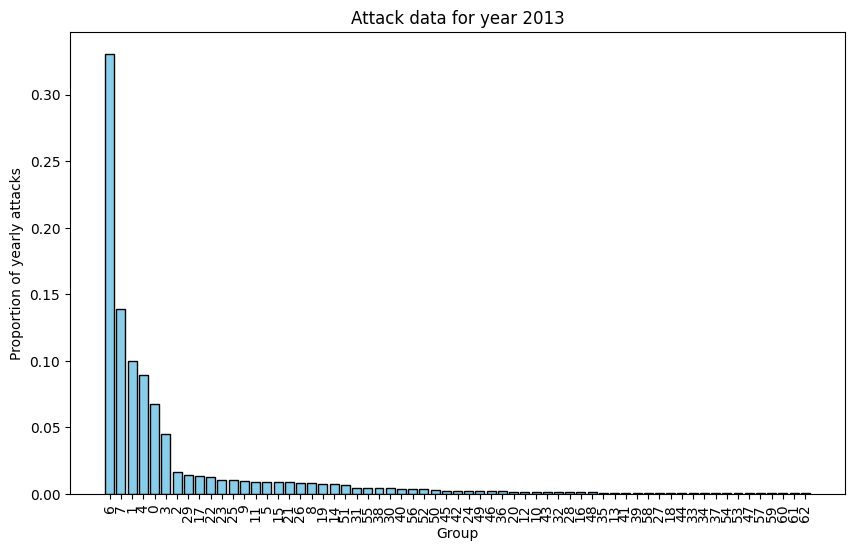

In [158]:
# Plotting the bar chart
group_counts = df_attack_network_year.group_int.value_counts()
x_axis = [str(x) for x in group_counts.index.to_numpy()]
y_axis = group_counts.to_numpy() / group_counts.to_numpy().sum()

plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='skyblue', edgecolor='black')

plt.title(f"Attack data for year {year}")
plt.xlabel("Group")
plt.ylabel("Proportion of yearly attacks")
plt.xticks(rotation=90)  # Ensure all years are displayed
plt.show()

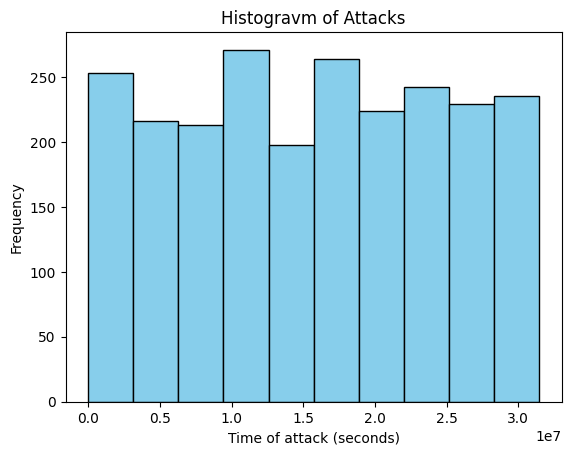

In [159]:
plt.hist(df_attack_network_year['seconds_since_earliest'], color='skyblue', edgecolor='black');
plt.title('Histogram of Attacks');
plt.xlabel('Time of attack (seconds)');
plt.ylabel('Frequency');
plt.show()